**A little statistics**

1. Converting a probability into a 'sigma'. As discussed in class, 'sigma' refers to a probability in physics. Our first task is to figure out how, given a probability, to calculate the assoicated 'sigma' value. The sigma implicitly refers to the standard normal distribution (a Gaussian with mean zero and standard deviation of 1). As we discussed in class, integrals of the standard normal distribution give probabilities.

A. Look up the Normal distribution and read about it. A few potential starting points: Math is fun, Wolfram, and a useful z table

In [2]:
# Completed

B. As in class, try integrating the standard normal distribution. This can be done either with the erfc(), or calls to specific statistical cumulative probability distributions such as stats.norm.cdf() in scipy. Try several values of sigma, and make sure you are getting values that match the z-table.




Used loop for integrating the standard normal distribution for several sigma values (1, 2, 3, and 5) to get their corresponding
probabilities and checking those results with the values in the z-table from wikipedia. 

For integrating of the standard normal curve from negative infinity to +s, the following equation was used:

$$\text{CDF}(s) = \int_{-\infty}^{s} \frac{1}{\sqrt{2\pi}} e^{-x^2/2} dx$$

Calculating one-tail probability utilized the following equation: 

$$P(X > s) = 1 - P(X \le s)$$

where the area underneath the curve was 1.0, so subtracting the left side left only the upper tail area. 

For calculating two-tail probability the following equation was used:

$$P(\vert{}X\vert{} > s) = P(X > s) + P(X < -s) = 2 \times (1 - \text{CDF}(s))$$

since the standard normal distribution curve is symmetric about zero. So the left tail (< -s) and right tail (> +s)
sides are identical. 

In [5]:
# Importing Packages
import numpy as np
from scipy import stats

In [6]:
# Defining standard sigmas for testing
sigmas = [1, 2, 3, 5]

# For loop applying each method to each defined sigma. 
for s in sigmas:
    # Calculating cumulative distribution function (CDF) at s standard deviations from the mean mu. 
    # Integrating the standard normal curve from - infinty to s. 
    cdf_val = stats.norm.cdf(s)

    # Calculating right tail probability.
    # Total area of curve is 1.0, so we can subtract the left side to give us the right tail probability.
    one_p_tail = 1 - cdf_val

    # Calculating two tail probability
    # Curve symmetric about 0, so left tail is the same as right tail, so we can multiply one_p_tail by 2.
    two_p_tail = 2 * (1 - cdf_val)

    # Printing out each sigma with its corresponding probabilities in terms of CDF, One-tailed, and Two-tailed.
    print(f"sigma-{s}:")
    print(f"CDF value: {cdf_val:.5f}")
    print(f"One-tail probability: {one_p_tail:.5e}")
    print(f"Two-tail probability: {two_p_tail:.5e}\n")

sigma-1:
CDF value: 0.84134
One-tail probability: 1.58655e-01
Two-tail probability: 3.17311e-01

sigma-2:
CDF value: 0.97725
One-tail probability: 2.27501e-02
Two-tail probability: 4.55003e-02

sigma-3:
CDF value: 0.99865
One-tail probability: 1.34990e-03
Two-tail probability: 2.69980e-03

sigma-5:
CDF value: 1.00000
One-tail probability: 2.86652e-07
Two-tail probability: 5.73303e-07



C. Now more often than not, we actually want to do the inverse: for a given probability determine the associated 'sigma' value: stats.norm.ppf() in python. Try several probability values where you know what the answer should be (e.g. Probability associated with 1, 2, 5 sigma), and show that you get the right answer in terms of sigma.

Now doing the inverse operation, where the known probability is used to get a corresponding sigma value.

$$\sigma = \Phi^{-1}\left(1 - \frac{p_{\text{2-tail}}}{2}\right)$$

Utilizing the 2-tail probabilities from part B's results as our known probabilities. Using cumulative_prob to 
convert to a one-sided cumulative percentile since stats.norm.ppf() doesn't know of the 2-tailed probability. 

$p/2$ is dividing the 2-tail probability in half so that the area in the upper right tail is isolated ($P(X>s)$).
Meanwhile $1 - (p/2)$ gets the total area to the left of +s by subtracting the upper right tail from 1.0 ($P(X<=s)$)

In [8]:
# Defining the standard 2-tail probabilities we found above corresponding to sigma 1, 2, 3, and 5. 
probs = [3.17311e-01, 4.55003e-02, 2.69980e-03, 5.73303e-07]

for p in probs:
    # Converting 2-tailed area into a one sided cumulative percentile from - infinity 
    cumulative_prob = 1 - (p/2) # p/2 divides the 2-tailed prob in half so right tailed area is isolated
    # 1 - (p/2) subtracts the upper right tail from 1.0 to get the total area to the left of +s.
    cor_sigma = stats.norm.ppf(cumulative_prob) # Finding sigma threshold x corresponding to that area

    print(f"Tail probability {p:.3e} -> Corresponding Sigma: {cor_sigma:.4f}")

Tail probability 3.173e-01 -> Corresponding Sigma: 1.0000
Tail probability 4.550e-02 -> Corresponding Sigma: 2.0000
Tail probability 2.700e-03 -> Corresponding Sigma: 3.0000
Tail probability 5.733e-07 -> Corresponding Sigma: 5.0000


D. If a minus sign appears, think about it and explain the meaning.

If a minus sign were to appear, it simply means that the value is on the left side of the mean $\mu$. This is because
the mean is equal to zero ($\mu$ = 0) so half of the area under the normal distribution curve lies below 0. 

2. Now let's explore some other continuous analytic distributions. Following the pattern from your first HW assigment, make both the analytic pdf() and a realization with ~100k samples using a built-in distribution; but this time don't use the Gaussian. Choose one of the following distributions: Rayleigh; Lognormal; Chi-Squared or Gamma; Exponential. You and your partner should choose different distributions.

I'm choosing to do the Chi-Squared distribution.

A. Read up on your distribution (wikipedia is your friend).

In [10]:
# Completed

B. Make plots (tweaking distribution and plot parameters as needed)

I chose the Chi-squared distribution. Degrees of freedom are going to dictate the shape and spread of the curve for my Chi-Squared distribution. 
The mean of the $\chi^2$ distribution is equal to the degrees of freedom k. I defined my parameter as 5, meaning 
the distribution is centered around $\mu$ = 5. Modified a good chunk of the homework code, but used the same skeleton for generating the 100k points, plotting parameters, linear histogram, log scale histogram, and theoretical curves. 

In [15]:
# Packages
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

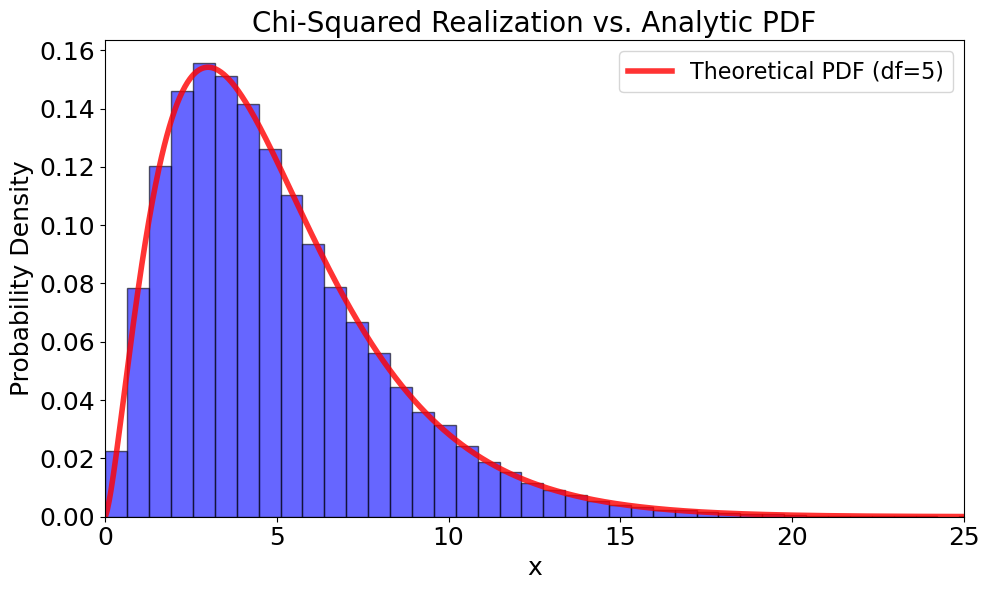

In [16]:
# Defining parameter for the number of degrees of freedom k
df = 5

# generating 100k random samples, df is dictating the shape and spread unlike the homework with mean and sigma.
d_chi2 = stats.chi2.rvs(df = df, size = 100000)

# Plotting boundaries for x-axis, chi-squared must remain positive
x_min, x_max = 0, 25

### Plot 1, Linear scale ###

fig, ax = plt.subplots(1, 1, figsize=(10, 6)) # Layout of 10 x 6 inches

# Sorting 100k random values into 50 bins from 0 to 25 boundaries. 
ax.hist(d_chi2, bins=50, density=True, color="blue", edgecolor="black", alpha=0.6)

## Overlaying the theoretical curve

# x-axis points for theoretical curve
x = np.linspace(x_min, x_max, 1000) # 1k evenly spaced points between x-axis boundaries

# Evaluating probability density function (PDF) at each of the 1k points
ax.plot(x, stats.chi2.pdf(x, df=df), color="red", linewidth=4, alpha=0.8, label=f"Theoretical PDF (df={df})")

# Plotting parameters
plt.tick_params(labelsize=18)
plt.xlim([x_min, x_max])
plt.xlabel("x", fontsize=18)
plt.ylabel("Probability Density", fontsize=18)
plt.title(f"Chi-Squared Realization vs. Analytic PDF", fontsize=20)
plt.legend(fontsize=16)
plt.tight_layout()
plt.show()

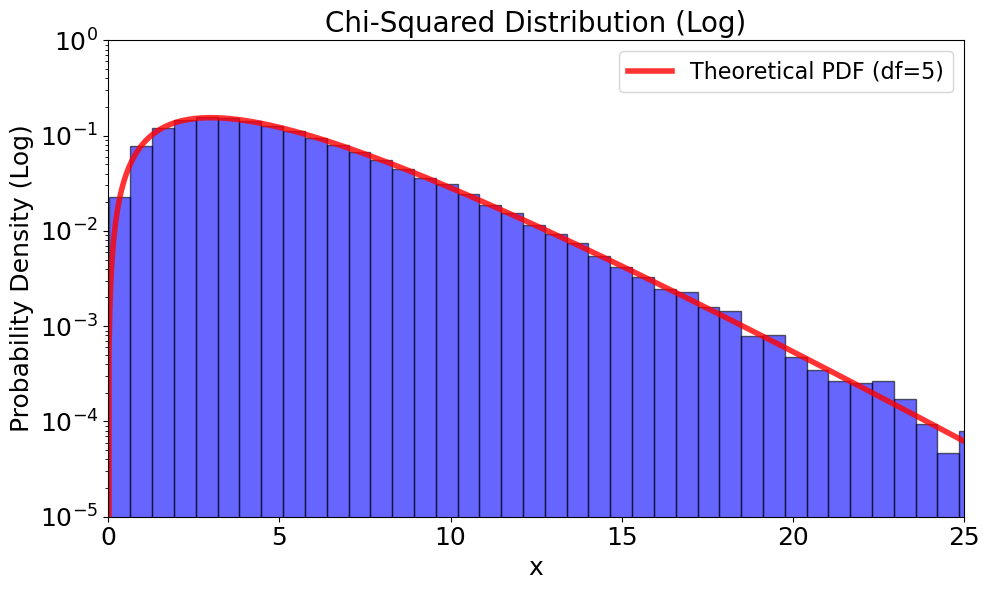

In [17]:
### Log scale plot, 2nd Plot ###

fig, ax = plt.subplots(1, 1, figsize=(10, 6)) # Layout of 10 x 6 inches

# Sorting 100k random values into 50 bins from 0 to 25 boundaries. 
ax.hist(d_chi2, bins=50, density=True, color="blue", edgecolor="black", alpha=0.6)

# Theoretical PDF plotted over the log-scaled graph
ax.plot(x, stats.chi2.pdf(x, df=df), color="red", linewidth=4, alpha=0.8, label=f"Theoretical PDF (df={df})")

# Setting my y-axis to log scale
plt.yscale("log")

# y-limit to avoid distortion near zero in the log scale
plt.ylim([1e-5, 1])

# Plotting parameters
plt.tick_params(labelsize=18)
plt.xlim([x_min, x_max])
plt.xlabel("x", fontsize=18)
plt.ylabel("Probability Density (Log)", fontsize=18)
plt.title(f"Chi-Squared Distribution (Log)", fontsize=20)
plt.legend(fontsize=16)
plt.tight_layout()
plt.show()

3. Imagine that your signal-free data follows the distribution you have chosen; and you have a measurement for which you need to determine the 'sigma'

A. Select a value for your hypothetical measurement

Since the mean $\mu$ = 5, I'll choose a higher value towards the right tail. My chosen value is **18**
It'll be a good starting point to represent excess signal. 

B. Clearly state the statistical question you want to ask in words

What's the probability that my value $18$, or any value higher than $18$ will be produced by a background fluctuation follwoing the $\chi^2$ distributiion with $5$ degrees of freedom (k = 5)? 

C. Convert your word question into a mathematical integral

Probability p equation:

$$p = P(X \ge 18.0) = \int_{18.0}^{\infty} f(x; k=5) \, dx$$

Which is rewritten when using the cumulative area from negative infinity to our hypothetical measurement:

$$p = 1 - \int_{0}^{18.0} f(x; k=5) \, dx = 1 - \text{CDF}_{\chi^2}(18.0; df=5)$$

D. Use the math to calculate the probability that the background produced the signal (Hint: you will want to use the statistics functions to do the integrals. .cdf() and .ppf() in scipy).

In [18]:
import scipy.stats as stats

In [23]:
df = 5 # Degrees of freedom for chi-squared
x_obs = 18.0 # My chosen hypothetical measurement

# Gives the probability P(X <= x_obs)
cdf_val = stats.chi2.cdf(x_obs, df=df)

# Right-tail probability P(X >= x_obs) = 1 - CDF
p_value = 1.0 - cdf_val

print(f"Background cumulative probability (P <= {x_obs}): {cdf_val:.6f}")
print(f"p-value (P >= {x_obs}): {p_value:.6e}")

Background cumulative probability (P <= 18.0): 0.997054
p-value (P >= 18.0): 2.946405e-03


E. Convert your probability into an equivalent 'sigma'

In [25]:
# Converting 1-tailed p-value to standard normal cumulative area
cumulative_norm_prob = 1.0 - p_value

# Finding the Gaussian sigma cutoff for our probability
corr_sigma = stats.norm.ppf(cumulative_norm_prob)

print(f"\nEquivalent Sigma: {corr_sigma:.4f} sigma")


Equivalent Sigma: 2.7537 sigma


4. Now explore a little bit. Try various hypothetical measurement values and see how the probabilities and 'sigmas' change. Discuss the patterns that you see.

In [29]:
# Keeping degrees of freedom constant so that mean remains the same. Going to test hypothetical measurements of:
# 2, 8, 12, 15, 20

#===== Hypothetical measurement 2.0 =====

df = 5 # Degrees of freedom for chi-squared
x_obs = 2.0 # My chosen hypothetical measurement

# Gives the probability P(X <= x_obs)
cdf_val = stats.chi2.cdf(x_obs, df=df)

# Right-tail probability P(X >= x_obs) = 1 - CDF
p_value = 1.0 - cdf_val

print(f"Background cumulative probability (P <= {x_obs}): {cdf_val:.6f}")
print(f"p-value (P >= {x_obs}): {p_value:.6e}")

# Converting 1-tailed p-value to standard normal cumulative area
cumulative_norm_prob = 1.0 - p_value

# Finding the Gaussian sigma cutoff for our probability
corr_sigma = stats.norm.ppf(cumulative_norm_prob)

print(f"\nEquivalent Sigma for hypothetical measurement of {x_obs}: {corr_sigma:.4f} sigma")

Background cumulative probability (P <= 2.0): 0.150855
p-value (P >= 2.0): 8.491450e-01

Equivalent Sigma for hypothetical measurement of 2.0: -1.0328 sigma


In [30]:
#===== Hypothetical measurement 8.0 =====

df = 5 # Degrees of freedom for chi-squared
x_obs = 8.0 # My chosen hypothetical measurement

# Gives the probability P(X <= x_obs)
cdf_val = stats.chi2.cdf(x_obs, df=df)

# Right-tail probability P(X >= x_obs) = 1 - CDF
p_value = 1.0 - cdf_val

print(f"Background cumulative probability (P <= {x_obs}): {cdf_val:.6f}")
print(f"p-value (P >= {x_obs}): {p_value:.6e}")

# Converting 1-tailed p-value to standard normal cumulative area
cumulative_norm_prob = 1.0 - p_value

# Finding the Gaussian sigma cutoff for our probability
corr_sigma = stats.norm.ppf(cumulative_norm_prob)

print(f"\nEquivalent Sigma for hypothetical measurement of {x_obs}: {corr_sigma:.4f} sigma")

Background cumulative probability (P <= 8.0): 0.843764
p-value (P >= 8.0): 1.562356e-01

Equivalent Sigma for hypothetical measurement of 8.0: 1.0101 sigma


In [31]:
#===== Hypothetical measurement 12.0 =====

df = 5 # Degrees of freedom for chi-squared
x_obs = 12.0 # My chosen hypothetical measurement

# Gives the probability P(X <= x_obs)
cdf_val = stats.chi2.cdf(x_obs, df=df)

# Right-tail probability P(X >= x_obs) = 1 - CDF
p_value = 1.0 - cdf_val

print(f"Background cumulative probability (P <= {x_obs}): {cdf_val:.6f}")
print(f"p-value (P >= {x_obs}): {p_value:.6e}")

# Converting 1-tailed p-value to standard normal cumulative area
cumulative_norm_prob = 1.0 - p_value

# Finding the Gaussian sigma cutoff for our probability
corr_sigma = stats.norm.ppf(cumulative_norm_prob)

print(f"\nEquivalent Sigma for hypothetical measurement of {x_obs}: {corr_sigma:.4f} sigma")

Background cumulative probability (P <= 12.0): 0.965212
p-value (P >= 12.0): 3.478778e-02

Equivalent Sigma for hypothetical measurement of 12.0: 1.8147 sigma


In [32]:
#===== Hypothetical measurement 15.0 =====

df = 5 # Degrees of freedom for chi-squared
x_obs = 15.0 # My chosen hypothetical measurement

# Gives the probability P(X <= x_obs)
cdf_val = stats.chi2.cdf(x_obs, df=df)

# Right-tail probability P(X >= x_obs) = 1 - CDF
p_value = 1.0 - cdf_val

print(f"Background cumulative probability (P <= {x_obs}): {cdf_val:.6f}")
print(f"p-value (P >= {x_obs}): {p_value:.6e}")

# Converting 1-tailed p-value to standard normal cumulative area
cumulative_norm_prob = 1.0 - p_value

# Finding the Gaussian sigma cutoff for our probability
corr_sigma = stats.norm.ppf(cumulative_norm_prob)

print(f"\nEquivalent Sigma for hypothetical measurement of {x_obs}: {corr_sigma:.4f} sigma")

Background cumulative probability (P <= 15.0): 0.989638
p-value (P >= 15.0): 1.036234e-02

Equivalent Sigma for hypothetical measurement of 15.0: 2.3130 sigma


In [33]:
#===== Hypothetical measurement 20.0 =====

df = 5 # Degrees of freedom for chi-squared
x_obs = 20.0 # My chosen hypothetical measurement

# Gives the probability P(X <= x_obs)
cdf_val = stats.chi2.cdf(x_obs, df=df)

# Right-tail probability P(X >= x_obs) = 1 - CDF
p_value = 1.0 - cdf_val

print(f"Background cumulative probability (P <= {x_obs}): {cdf_val:.6f}")
print(f"p-value (P >= {x_obs}): {p_value:.6e}")

# Converting 1-tailed p-value to standard normal cumulative area
cumulative_norm_prob = 1.0 - p_value

# Finding the Gaussian sigma cutoff for our probability
corr_sigma = stats.norm.ppf(cumulative_norm_prob)

print(f"\nEquivalent Sigma for hypothetical measurement of {x_obs}: {corr_sigma:.4f} sigma")

Background cumulative probability (P <= 20.0): 0.998750
p-value (P >= 20.0): 1.249731e-03

Equivalent Sigma for hypothetical measurement of 20.0: 3.0234 sigma


After testing various hypothetical measurements of $2.0$, $8.0$, $12.0$, $15.0$, and $20.0$, I noticed some patterns with the 
probabilities and sigmas. The sigmas seemed to continue increasing as the hypothetical measurements increased in value. It seems to be follow a logorithmic growth curve sort of from what I can see. For the probabilites, the p-value seems to be approaching closer and closer to zero as the hypothetical measurement values increase and the background cumulative probability seems to be increasing linearly as the hypothetical measurement value increases. 